# **Análisis de factores de Detracción en el Campus Cusco**

# **Importar paquetes**

In [41]:
import pandas as pd
import os
import sys
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, confusion_matrix
import seaborn as sns

# **Preparación del acceso al Drive**

In [42]:
from google.colab import drive
drive.mount('/content/drive')


# Get the current directory of the notebook
current_dir = os.getcwd()

# Construct the path to the utilidadesML directory (assuming it's in the same directory as the notebook)
utilidadesML_path = os.path.join(current_dir, "drive/MyDrive/GSANCHEZH.GIT.HUB/PruebasML")

# Add the utilidadesML directory to the Python path
sys.path.append(utilidadesML_path)

import utilidadesML as ml

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Lectura de los datos**

In [43]:
from google.colab import drive
drive.mount('/content/drive')
estudiantes = pd.read_csv('drive/MyDrive/GSANCHEZH.GIT.HUB/PruebasML/DATANPS2025.csv', sep=";")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Análisis de correlaciones para Detractores**

In [44]:
estudiantes_CUSCO = estudiantes[estudiantes['X_CAMPUS'] == 'CZC'].copy()
estudiantes_CUSCO.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1794 entries, 3 to 7893
Data columns (total 77 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID_COD                 1794 non-null   int64  
 1   ID                     1794 non-null   int64  
 2   X_CAMPUS               1794 non-null   object 
 3   X_PERIODO              1794 non-null   object 
 4   X_MODALIDAD            1794 non-null   object 
 5   PROGRAMA               1794 non-null   int64  
 6   X_FACULTAD             1794 non-null   object 
 7   DESCRIPCION_PROGRAMA   1794 non-null   object 
 8   PERIODO_ADMISION       1794 non-null   int64  
 9   CATALOGO               1794 non-null   int64  
 10  CICLO_ACTUAL           1794 non-null   int64  
 11  CREDITOS_TOTAL         1794 non-null   int64  
 12  CREDITOS_MATRICULADOS  1794 non-null   int64  
 13  CACHIMBO               1794 non-null   int64  
 14  CICLO_MUESTRA          1794 non-null   object 
 15  REINCORPO

**Trabajo solo con las columnas de satisfacción General**

In [45]:
copia = X = estudiantes_CUSCO[['DETRACTOR', 'SATIF_ACAD', 'SATISF_SERV', 'SATISF_EXP', 'SATISF_REG_ACAD', 'SATISF_ACT_SOST', 'SATISF_APY_LOGRO_ACAD', 'SATISF_INF_TEC', 'SATISF_CAMP_VIRT', 'SATISF_COM_IMAG']]


**Matriz de correlaciones**

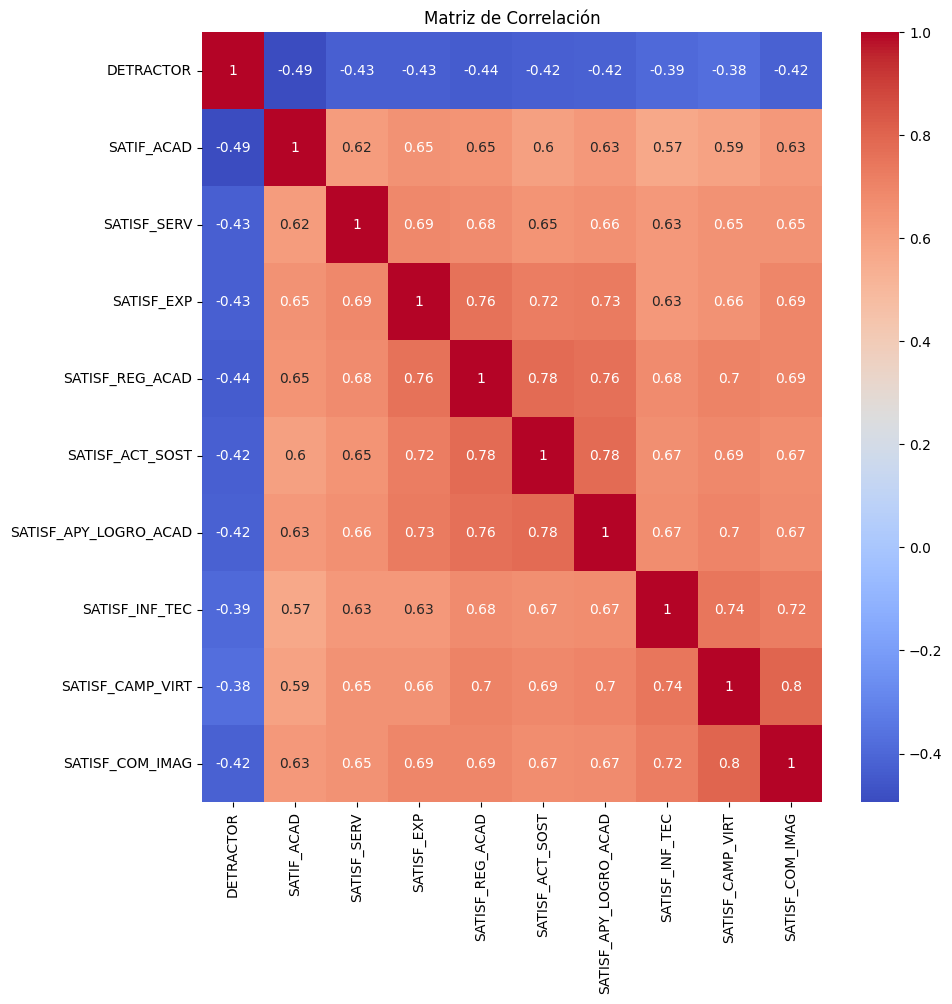

In [46]:
plt.figure(figsize=(10, 10))
sns.heatmap(copia.corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

# **Preparación de conjuntos de extrenamiento y testing**

In [47]:
X = estudiantes_CUSCO[['SATIF_ACAD', 'SATISF_SERV', 'SATISF_EXP', 'SATISF_REG_ACAD', 'SATISF_ACT_SOST', 'SATISF_APY_LOGRO_ACAD', 'SATISF_INF_TEC', 'SATISF_CAMP_VIRT', 'SATISF_COM_IMAG']]
y = estudiantes_CUSCO['DETRACTOR']
XCopia = X.copy()

# **Pruebas T de Diferencia de Medias para refinar las columnas del Modelo el conjunto final queda en XCopia**

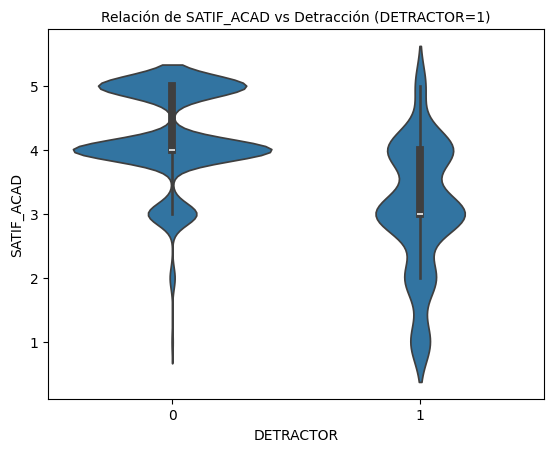

*** Prueba t para SATIF_ACAD ***
Estadístico t: -24.05771
Valor p: 0.00000
Se rechaza la hipótesis nula. Las medias son significativamente diferentes.
DETRACTOR
0    4.214774
1    3.075301
Name: SATIF_ACAD, dtype: float64




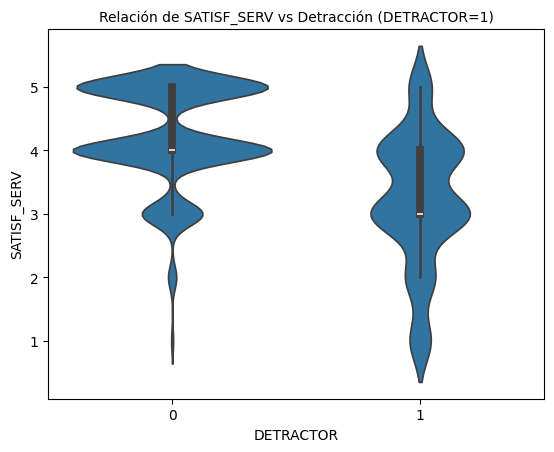

*** Prueba t para SATISF_SERV ***
Estadístico t: -19.92851
Valor p: 0.00000
Se rechaza la hipótesis nula. Las medias son significativamente diferentes.
DETRACTOR
0    4.235978
1    3.231928
Name: SATISF_SERV, dtype: float64




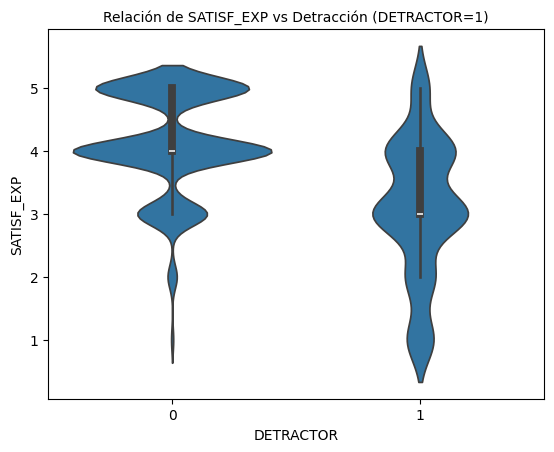

*** Prueba t para SATISF_EXP ***
Estadístico t: -20.12697
Valor p: 0.00000
Se rechaza la hipótesis nula. Las medias son significativamente diferentes.
DETRACTOR
0    4.136799
1    3.096386
Name: SATISF_EXP, dtype: float64




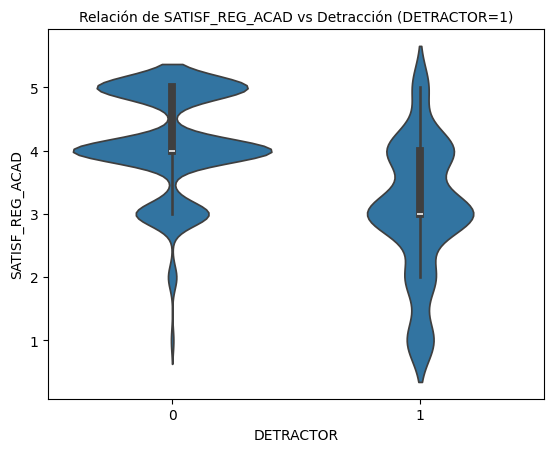

*** Prueba t para SATISF_REG_ACAD ***
Estadístico t: -20.68550
Valor p: 0.00000
Se rechaza la hipótesis nula. Las medias son significativamente diferentes.
DETRACTOR
0    4.125171
1    3.063253
Name: SATISF_REG_ACAD, dtype: float64




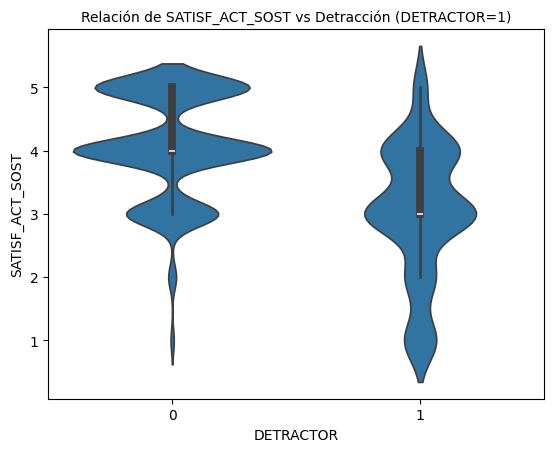

*** Prueba t para SATISF_ACT_SOST ***
Estadístico t: -19.83535
Valor p: 0.00000
Se rechaza la hipótesis nula. Las medias son significativamente diferentes.
DETRACTOR
0    4.082763
1    3.042169
Name: SATISF_ACT_SOST, dtype: float64




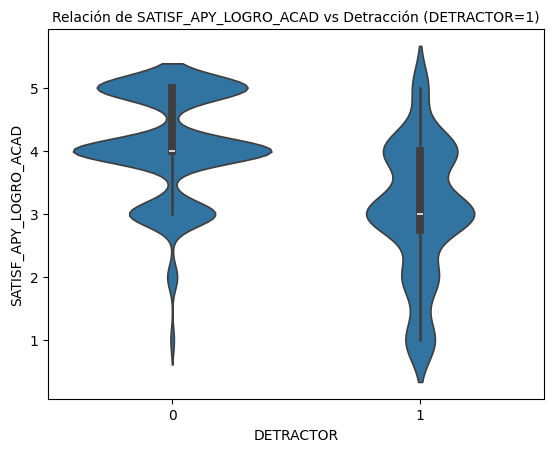

*** Prueba t para SATISF_APY_LOGRO_ACAD ***
Estadístico t: -19.62471
Valor p: 0.00000
Se rechaza la hipótesis nula. Las medias son significativamente diferentes.
DETRACTOR
0    4.077291
1    3.039157
Name: SATISF_APY_LOGRO_ACAD, dtype: float64




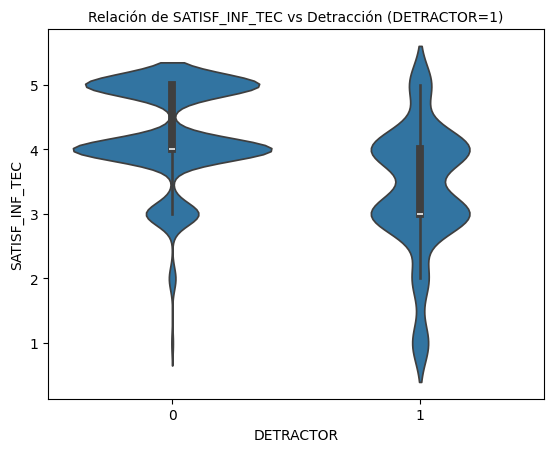

*** Prueba t para SATISF_INF_TEC ***
Estadístico t: -18.04310
Valor p: 0.00000
Se rechaza la hipótesis nula. Las medias son significativamente diferentes.
DETRACTOR
0    4.240082
1    3.373494
Name: SATISF_INF_TEC, dtype: float64




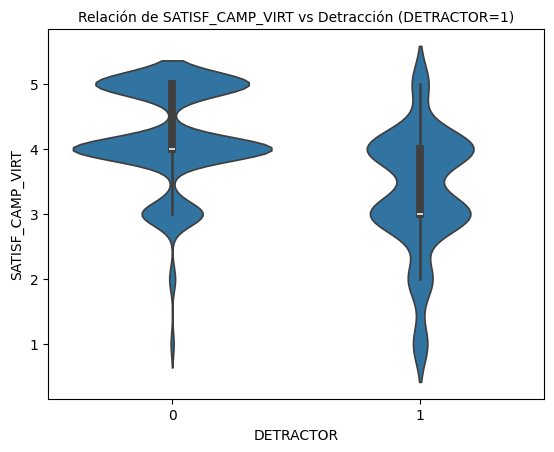

*** Prueba t para SATISF_CAMP_VIRT ***
Estadístico t: -17.21419
Valor p: 0.00000
Se rechaza la hipótesis nula. Las medias son significativamente diferentes.
DETRACTOR
0    4.171683
1    3.331325
Name: SATISF_CAMP_VIRT, dtype: float64




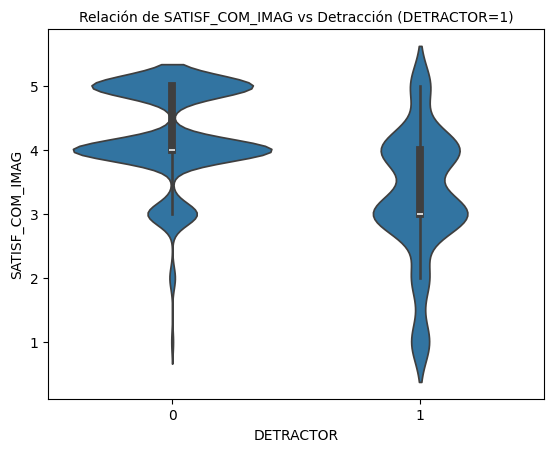

*** Prueba t para SATISF_COM_IMAG ***
Estadístico t: -19.66992
Valor p: 0.00000
Se rechaza la hipótesis nula. Las medias son significativamente diferentes.
DETRACTOR
0    4.230506
1    3.283133
Name: SATISF_COM_IMAG, dtype: float64




In [48]:
for column in X.columns:
    title = f"Relación de {column} vs Detracción (DETRACTOR=1)"
    ml.analisis_variable_violin(estudiantes_CUSCO, "DETRACTOR", column, title)
    ml.prueba_t(estudiantes_CUSCO, 'DETRACTOR', column, 1, 0, XCopia)

# **Modelo de Regresión Logística para predecir Detractores**

**Separación de conjuntos de Entrenamiento y Pruebas**

In [49]:
X_train, X_test, y_train, y_test = train_test_split(XCopia, y, test_size=0.20, random_state=42)

**Configuración del Modelo de Regresión Logística**

In [50]:
model_balanced = LogisticRegression(solver='liblinear', max_iter=500, random_state=50, class_weight='balanced')

**Entrenamiento del Modelo "Aprendizaje"**

In [51]:
model_balanced.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=500, random_state=50,
                   solver='liblinear')

**Pruebas: Uso de Conjunto de Entrenamiento**

In [52]:
y_pred_balanced = model_balanced.predict(X_test)

**Matriz de Confusión**

Precisión del modelo con class_weight='balanced': 0.816
Reporte de clasificación con class_weight='balanced':
              precision    recall  f1-score   support

           0       0.95      0.82      0.88       294
           1       0.50      0.78      0.61        65

    accuracy                           0.82       359
   macro avg       0.72      0.80      0.74       359
weighted avg       0.86      0.82      0.83       359



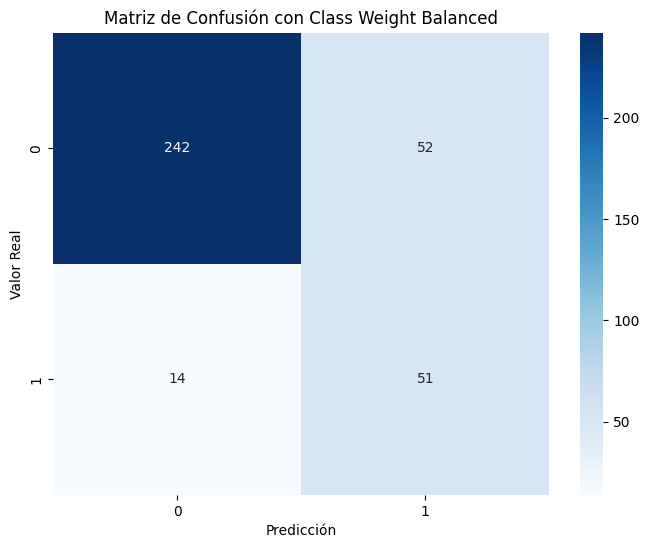

In [53]:
## Cáculo de la Matriz de Confusión
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
report_balanced = classification_report(y_test, y_pred_balanced)

print(f'Precisión del modelo con class_weight=\'balanced\': {accuracy_balanced:.3f}')
print(f'Reporte de clasificación con class_weight=\'balanced\':\n{report_balanced}')

# Graficar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_balanced), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión con Class Weight Balanced')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

### **Análisis de la Importancia de las Variables (`model_balanced`)**

SATIF_ACAD: -0.94
SATISF_SERV: -0.21
SATISF_EXP: 0.10
SATISF_REG_ACAD: -0.08
SATISF_ACT_SOST: -0.27
SATISF_APY_LOGRO_ACAD: -0.21
SATISF_INF_TEC: -0.10
SATISF_CAMP_VIRT: 0.32
SATISF_COM_IMAG: -0.35


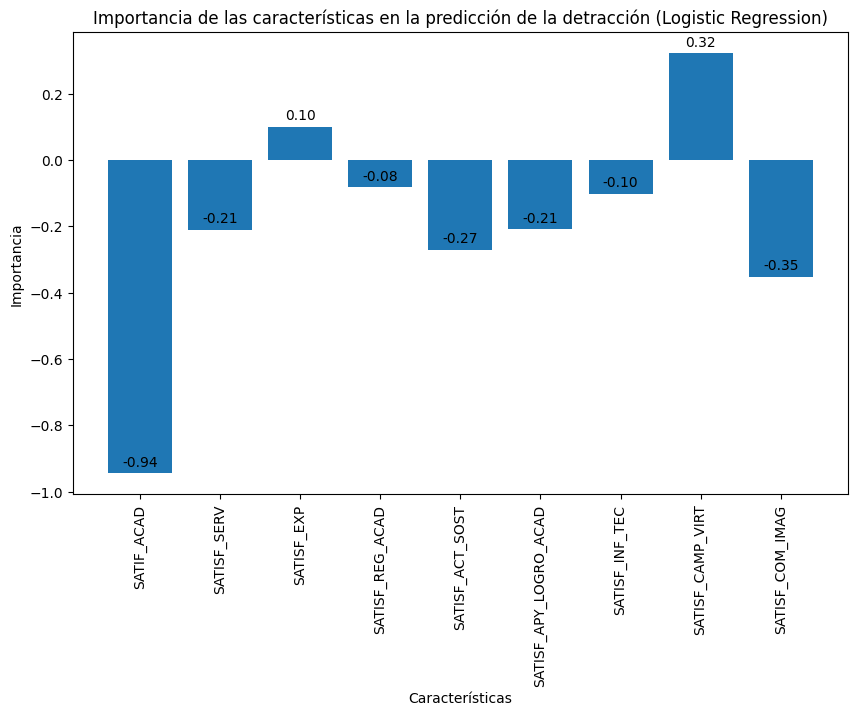

In [54]:
feature_importance = model_balanced.coef_[0]

for i in range(0, len(XCopia.columns)):
    print(f"{XCopia.columns[i]}: {feature_importance[i]:.2f}")

plt.figure(figsize=(10, 6))
bars = plt.bar(XCopia.columns, feature_importance)
plt.xlabel('Características')
plt.ylabel('Importancia')
plt.title('Importancia de las características en la predicción de la detracción (Logistic Regression)')

for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.xticks(rotation=90)
plt.show()

### **Análisis SHA: Uso de Deep Learning para saber la importancia de las variables en el resultado del modelo**

In [55]:
import shap

explainer = shap.KernelExplainer(model_balanced.predict, shap.kmeans(X_train, 100))
shap_values = explainer.shap_values(X_test)


  0%|          | 0/359 [00:00<?, ?it/s]

**Gráfico de barras**

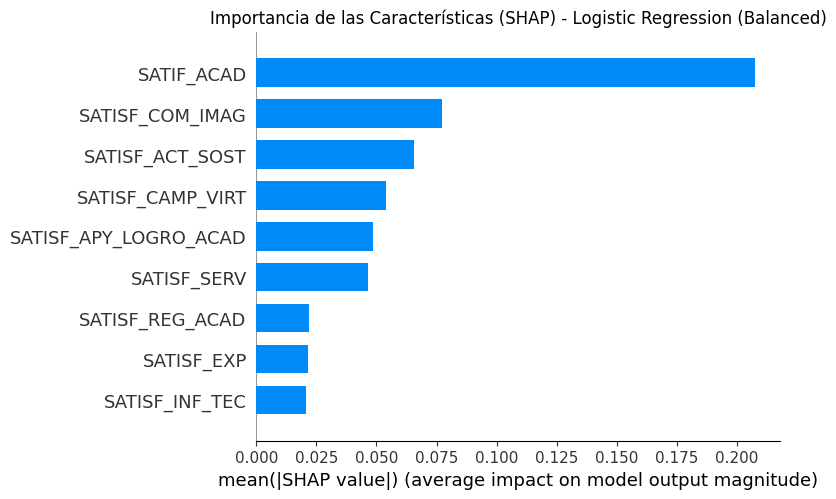

In [56]:
plt.title('Importancia de las Características (SHAP) - Logistic Regression (Balanced)')
shap.summary_plot(shap_values, X_test, feature_names=XCopia.columns, plot_type="bar")

**Gráfico de calor**

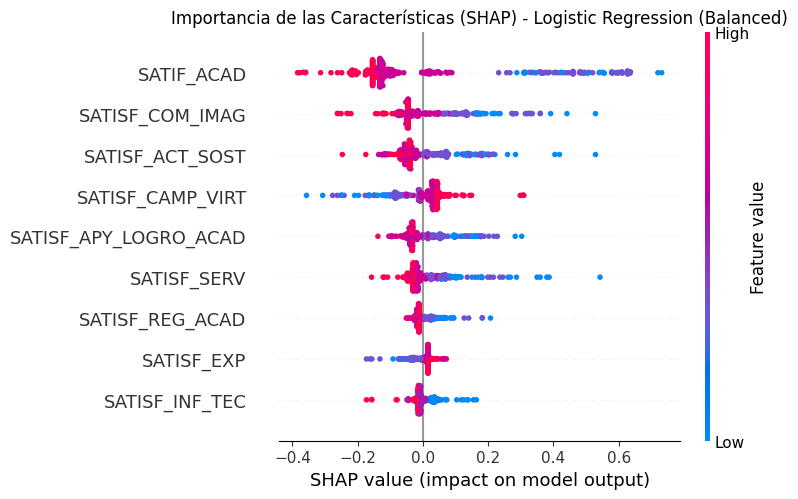

In [57]:
plt.title('Importancia de las Características (SHAP) - Logistic Regression (Balanced)')
shap.summary_plot(shap_values, X_test, feature_names=XCopia.columns)

# **Análisis de los factores de Satisfacción lo académico**
**P3. ¿QUÉ TAN SATISFECHO TE ENCUENTRAS CON EL ÁREA ACADÉMICA DE LA UNIVERSIDAD CONTINENTAL?**

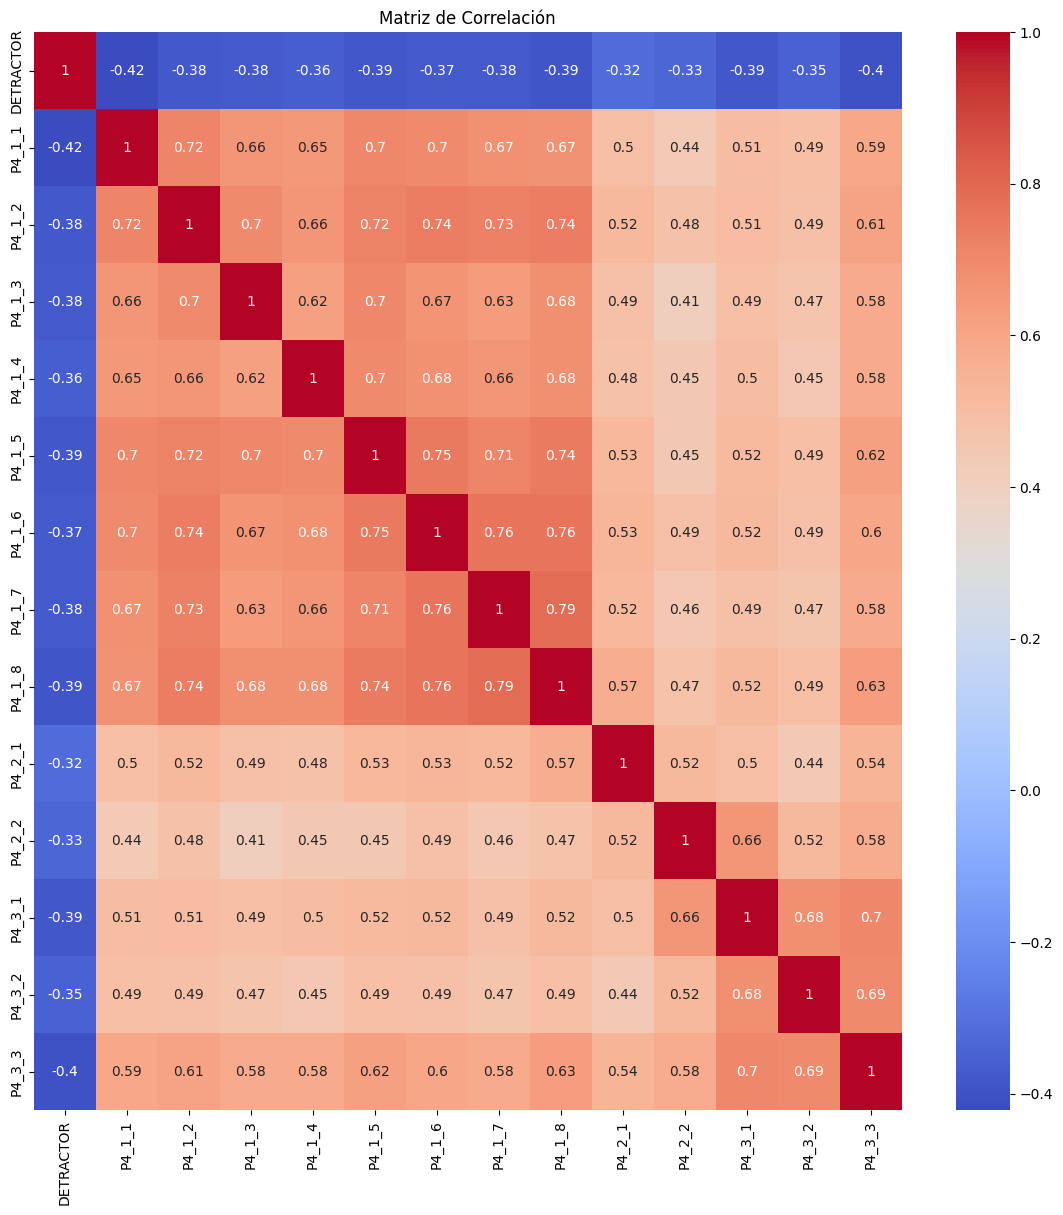

In [58]:
copia = X = estudiantes_CUSCO[['DETRACTOR','P4_1_1','P4_1_2','P4_1_3','P4_1_4','P4_1_5','P4_1_6','P4_1_7','P4_1_8','P4_2_1','P4_2_2','P4_3_1','P4_3_2','P4_3_3']]
plt.figure(figsize=(14, 14))
sns.heatmap(copia.corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

**Extracción de as variables de las subcomponnetes de la Satisfacción Académica**

In [59]:
X = estudiantes_CUSCO[['P4_1_1','P4_1_2','P4_1_3','P4_1_4','P4_1_5','P4_1_6','P4_1_7','P4_1_8','P4_2_1','P4_2_2','P4_3_1','P4_3_2','P4_3_3']]
y = estudiantes_CUSCO['DETRACTOR']
XCopia = X.copy()

**Pruebas T de Diferencia de Medias para refinar las columnas del Modelo el conjunto final queda en XCopia**

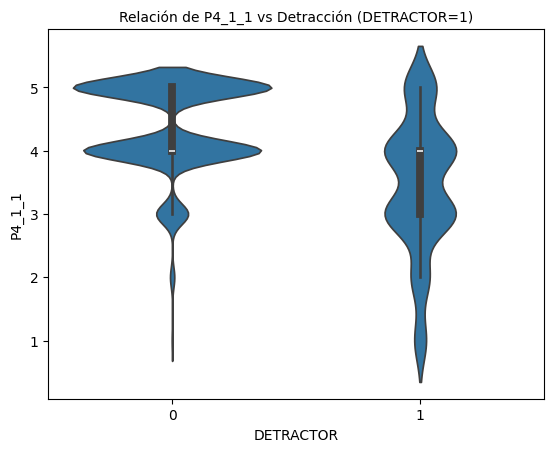

*** Prueba t para P4_1_1 ***
Estadístico t: -19.68279
Valor p: 0.00000
Se rechaza la hipótesis nula. Las medias son significativamente diferentes.
DETRACTOR
0    4.376197
1    3.457831
Name: P4_1_1, dtype: float64




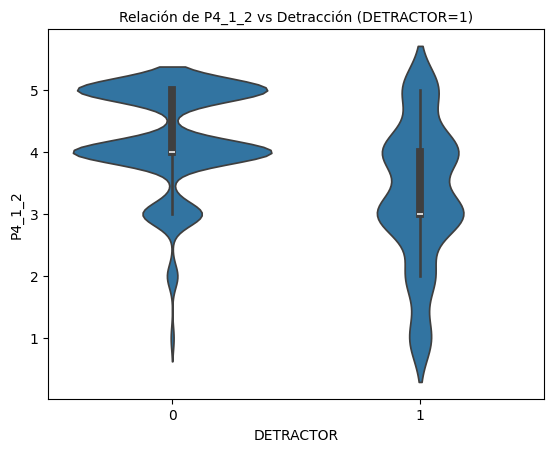

*** Prueba t para P4_1_2 ***
Estadístico t: -17.40127
Valor p: 0.00000
Se rechaza la hipótesis nula. Las medias son significativamente diferentes.
DETRACTOR
0    4.219562
1    3.301205
Name: P4_1_2, dtype: float64




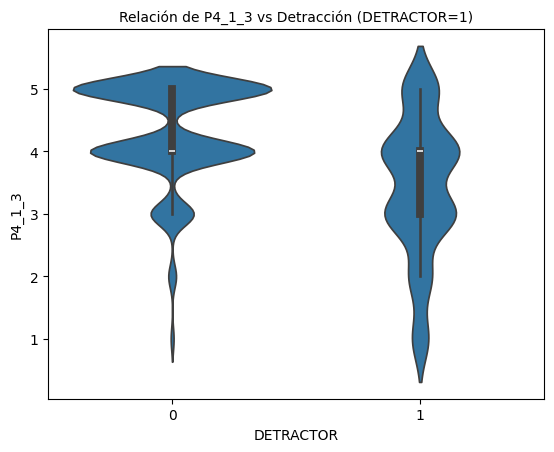

*** Prueba t para P4_1_3 ***
Estadístico t: -17.20555
Valor p: 0.00000
Se rechaza la hipótesis nula. Las medias son significativamente diferentes.
DETRACTOR
0    4.316005
1    3.424699
Name: P4_1_3, dtype: float64




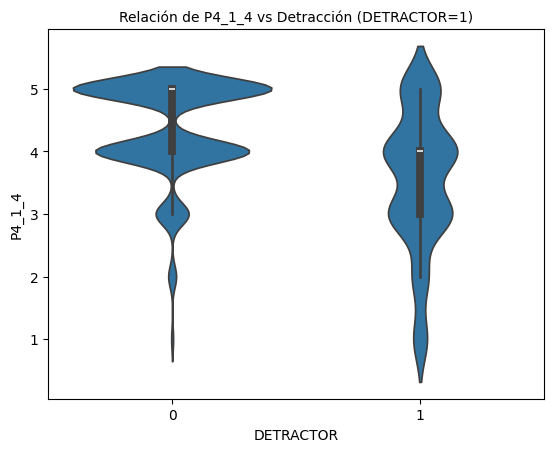

*** Prueba t para P4_1_4 ***
Estadístico t: -16.54274
Valor p: 0.00000
Se rechaza la hipótesis nula. Las medias son significativamente diferentes.
DETRACTOR
0    4.365253
1    3.530120
Name: P4_1_4, dtype: float64




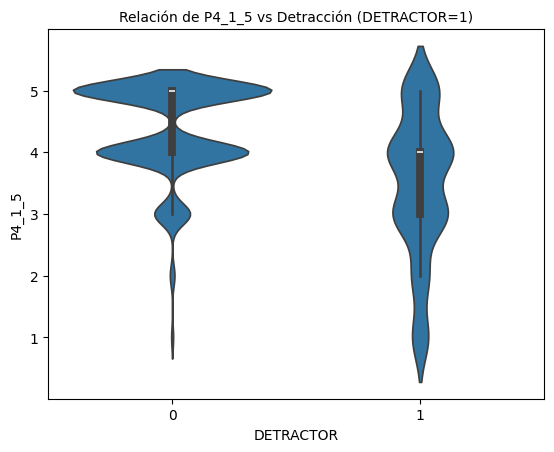

*** Prueba t para P4_1_5 ***
Estadístico t: -17.83171
Valor p: 0.00000
Se rechaza la hipótesis nula. Las medias son significativamente diferentes.
DETRACTOR
0    4.376197
1    3.475904
Name: P4_1_5, dtype: float64




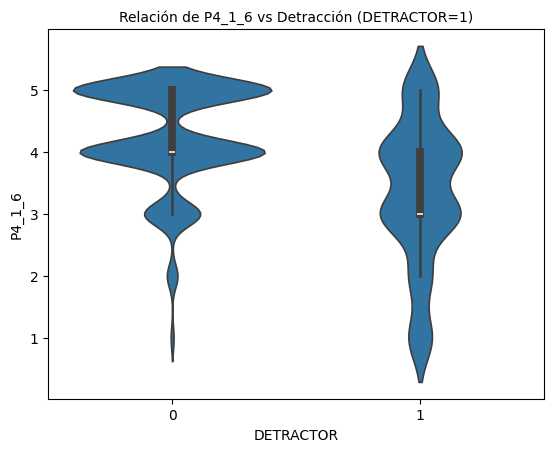

*** Prueba t para P4_1_6 ***
Estadístico t: -17.08111
Valor p: 0.00000
Se rechaza la hipótesis nula. Las medias son significativamente diferentes.
DETRACTOR
0    4.248974
1    3.340361
Name: P4_1_6, dtype: float64




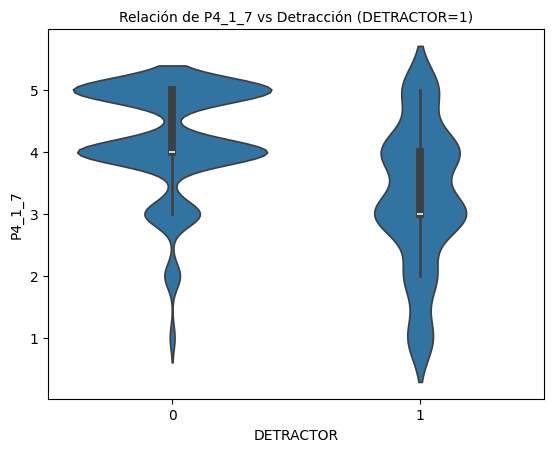

*** Prueba t para P4_1_7 ***
Estadístico t: -17.17509
Valor p: 0.00000
Se rechaza la hipótesis nula. Las medias son significativamente diferentes.
DETRACTOR
0    4.209986
1    3.256024
Name: P4_1_7, dtype: float64




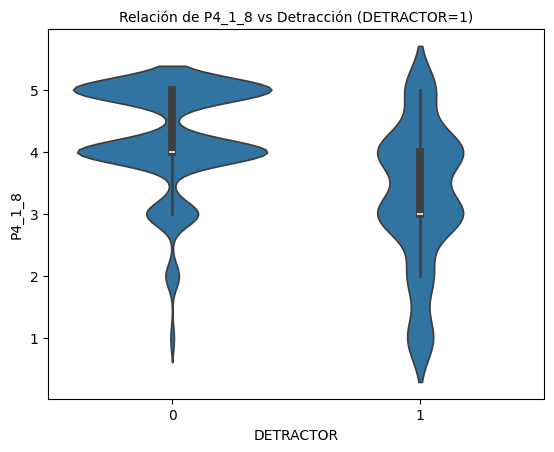

*** Prueba t para P4_1_8 ***
Estadístico t: -17.97325
Valor p: 0.00000
Se rechaza la hipótesis nula. Las medias son significativamente diferentes.
DETRACTOR
0    4.238714
1    3.271084
Name: P4_1_8, dtype: float64




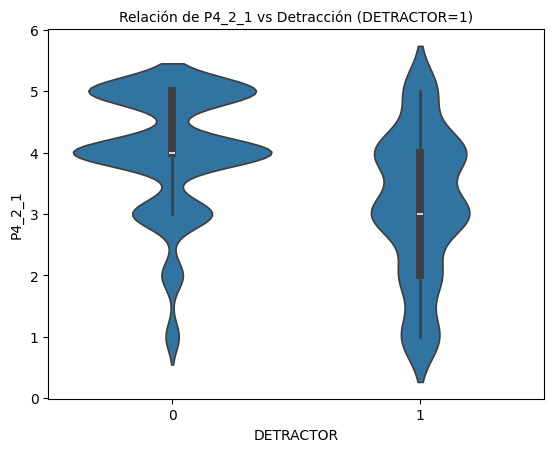

*** Prueba t para P4_2_1 ***
Estadístico t: -14.31312
Valor p: 0.00000
Se rechaza la hipótesis nula. Las medias son significativamente diferentes.
DETRACTOR
0    4.011628
1    3.132530
Name: P4_2_1, dtype: float64




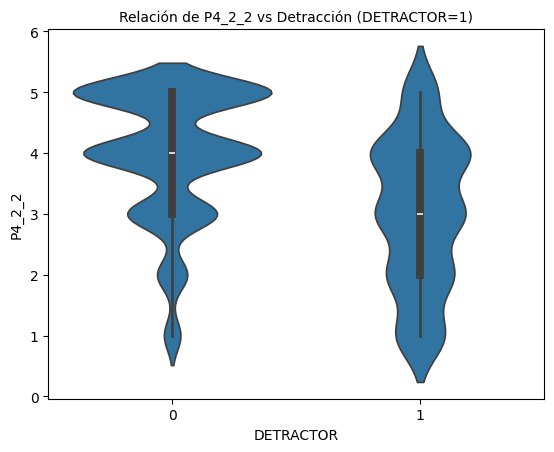

*** Prueba t para P4_2_2 ***
Estadístico t: -15.00656
Valor p: 0.00000
Se rechaza la hipótesis nula. Las medias son significativamente diferentes.
DETRACTOR
0    3.997948
1    3.015060
Name: P4_2_2, dtype: float64




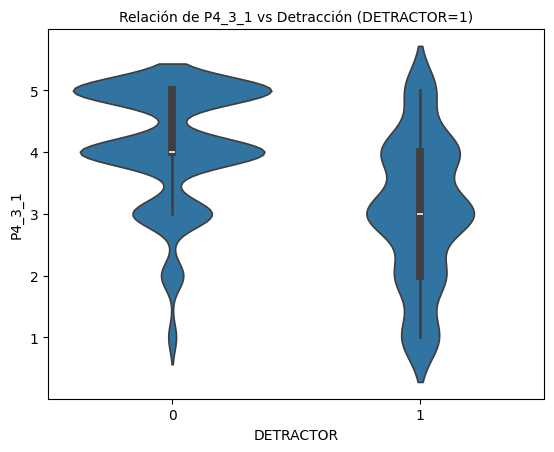

*** Prueba t para P4_3_1 ***
Estadístico t: -17.72882
Valor p: 0.00000
Se rechaza la hipótesis nula. Las medias son significativamente diferentes.
DETRACTOR
0    4.103967
1    3.048193
Name: P4_3_1, dtype: float64




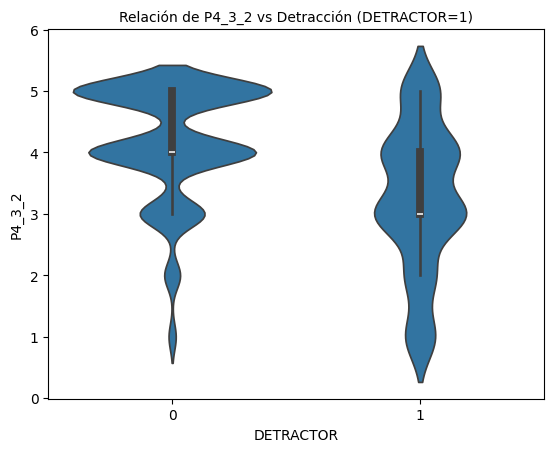

*** Prueba t para P4_3_2 ***
Estadístico t: -15.97059
Valor p: 0.00000
Se rechaza la hipótesis nula. Las medias son significativamente diferentes.
DETRACTOR
0    4.177839
1    3.240964
Name: P4_3_2, dtype: float64




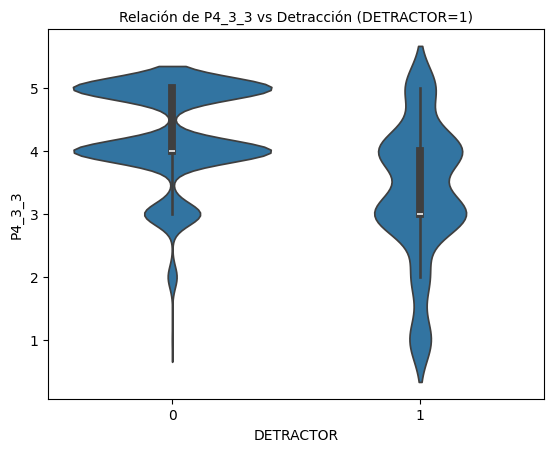

*** Prueba t para P4_3_3 ***
Estadístico t: -18.58760
Valor p: 0.00000
Se rechaza la hipótesis nula. Las medias son significativamente diferentes.
DETRACTOR
0    4.266758
1    3.337349
Name: P4_3_3, dtype: float64




In [60]:
for column in X.columns:
    title = f"Relación de {column} vs Detracción (DETRACTOR=1)"
    ml.analisis_variable_violin(estudiantes_CUSCO, "DETRACTOR", column, title)
    ml.prueba_t(estudiantes_CUSCO, 'DETRACTOR', column, 1, 0, XCopia)

**Configuración del Modelo**

Precisión del modelo con class_weight='balanced': 0.786
Reporte de clasificación con class_weight='balanced':
              precision    recall  f1-score   support

           0       0.94      0.79      0.86       294
           1       0.45      0.77      0.56        65

    accuracy                           0.79       359
   macro avg       0.69      0.78      0.71       359
weighted avg       0.85      0.79      0.80       359



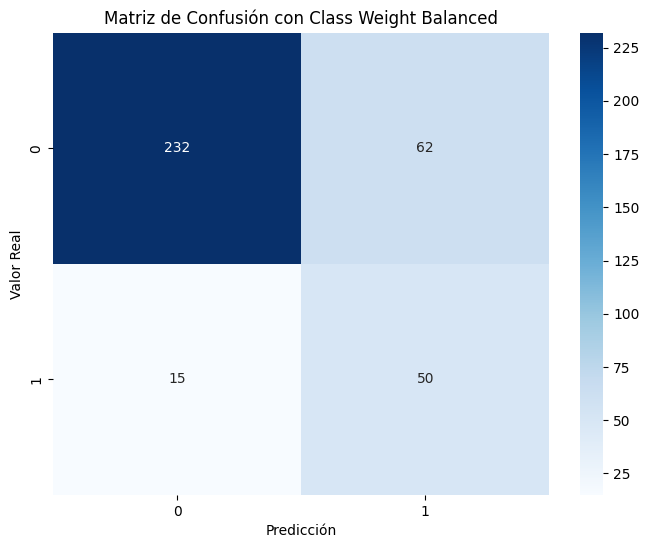

In [61]:
# Modelo de Regresión Logística con class_weight='balanced'
# Esto asignará automáticamente pesos inversamente proporcionales a las frecuencias de clase.

X_train, X_test, y_train, y_test = train_test_split(XCopia, y, test_size=0.2, random_state=42)

model_balanced = LogisticRegression(solver='liblinear', max_iter=300, random_state=50, class_weight='balanced')

model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
report_balanced = classification_report(y_test, y_pred_balanced)

print(f'Precisión del modelo con class_weight=\'balanced\': {accuracy_balanced:.3f}')
print(f'Reporte de clasificación con class_weight=\'balanced\':\n{report_balanced}')

# Graficar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_balanced), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión con Class Weight Balanced')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

**4.1.1 CONOCIMIENTO Y DOMINIO DE LA ASIGNATURA POR PARTE DEL DOCENTE**

**4.1.8 EL SEGUIMIENTO DEL DESEMPEÑO DEL ESTUDIANTE ACOMPAÑADO DE RETROALIMENTACIÓN CONSTRUCTIVA SOBRE TRABAJOS, PROYECTOS Y ENTREGABLES**

**4.3.1 FLEXIBILIDAD PARA LA ELECCIÓN DE ASIGNATURAS DEL PLAN DE ESTUDIOS**

**4.2.2 LOS HORARIOS DE CLASE SON ADECUADOS Y SE AJUSTAN A LA DISPONIBILIDAD Y REQUERIMIENTOS DE LOS ESTUDIANTES**

  0%|          | 0/359 [00:00<?, ?it/s]

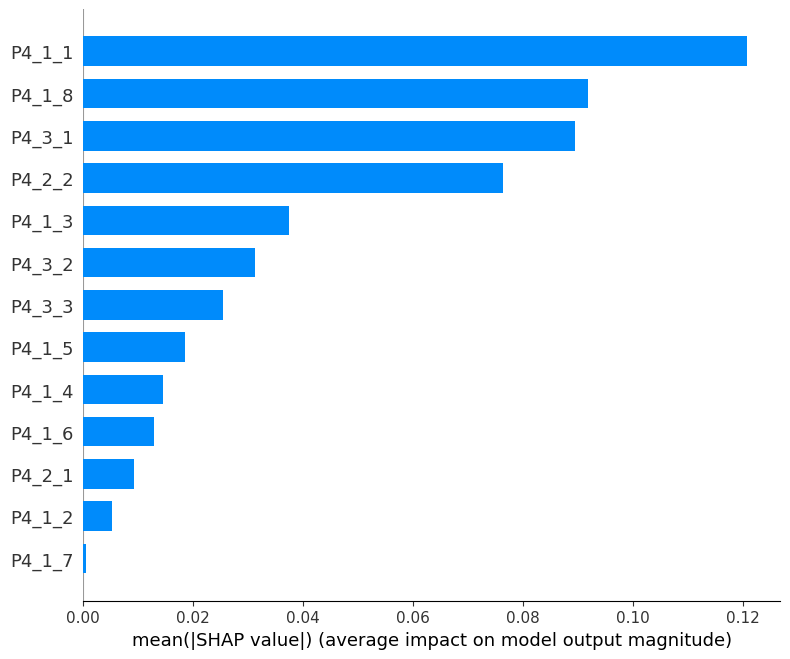

In [62]:
import shap

explainer = shap.KernelExplainer(model_balanced.predict, shap.kmeans(X_train, 100))
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=XCopia.columns, plot_type="bar")

**Gráfico de calor:**

 **Si ves puntos rojos en el lado izquierdo y azules en el derecho esto significa valores altos de la característica disminuyen la probabilidad de ser detractor y valores bajos la aumentan**

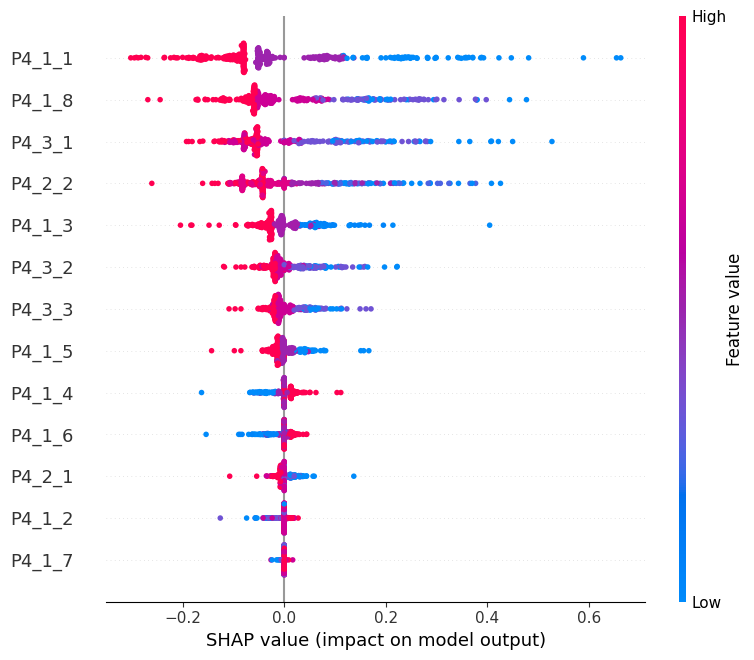

In [63]:
shap.summary_plot(shap_values, X_test, feature_names=XCopia.columns)

# **Análisis de los factores de Satisfacción con la Imagen y Comunicación de la universidad**

**P26. ¿QUÉ TAN SATISFECHO TE ENCUENTRAS CON CADA UNO DE LOS ASPECTOS DE LA COMUNICACIÓN E IMAGEN   DE LA UNIVERSIDAD CONTINENTAL?**

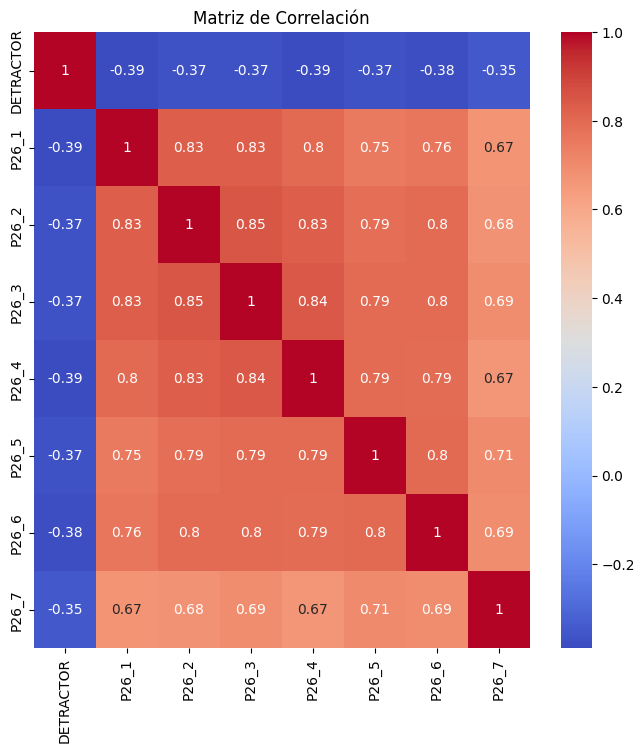

In [64]:
copia = X = estudiantes_CUSCO[['DETRACTOR','P26_1','P26_2','P26_3','P26_4','P26_5','P26_6','P26_7']]
plt.figure(figsize=(8, 8))
sns.heatmap(copia.corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

In [65]:
X = estudiantes_CUSCO[['P26_1','P26_2','P26_3','P26_4','P26_5','P26_6','P26_7']]
y = estudiantes_CUSCO['DETRACTOR']
XCopia = X.copy()

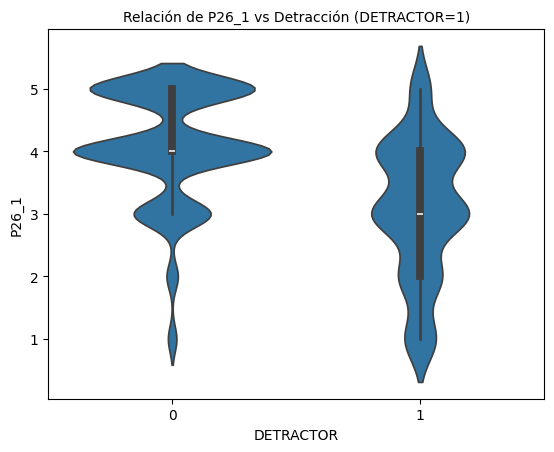

*** Prueba t para P26_1 ***
Estadístico t: -17.76763
Valor p: 0.00000
Se rechaza la hipótesis nula. Las medias son significativamente diferentes.
DETRACTOR
0    4.086867
1    3.084337
Name: P26_1, dtype: float64




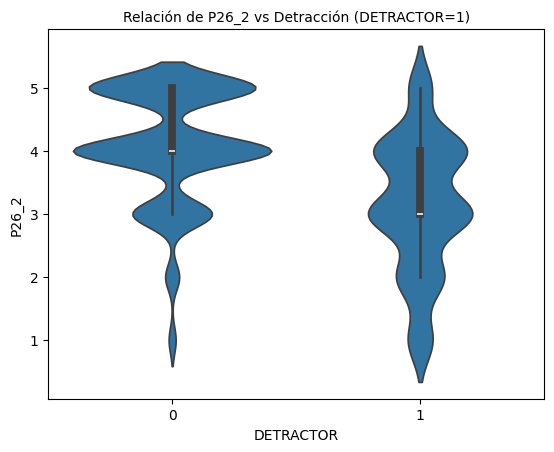

*** Prueba t para P26_2 ***
Estadístico t: -16.81455
Valor p: 0.00000
Se rechaza la hipótesis nula. Las medias son significativamente diferentes.
DETRACTOR
0    4.082079
1    3.144578
Name: P26_2, dtype: float64




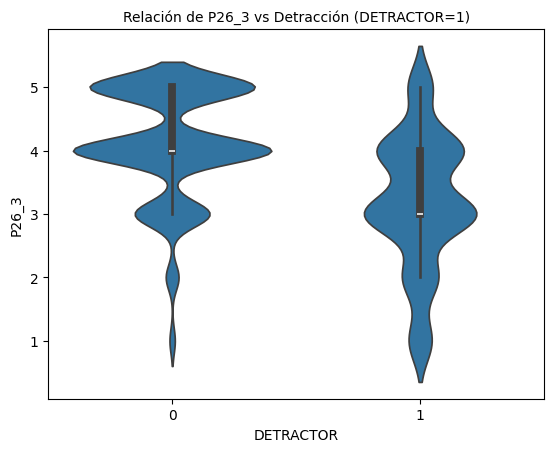

*** Prueba t para P26_3 ***
Estadístico t: -16.85794
Valor p: 0.00000
Se rechaza la hipótesis nula. Las medias son significativamente diferentes.
DETRACTOR
0    4.106703
1    3.192771
Name: P26_3, dtype: float64




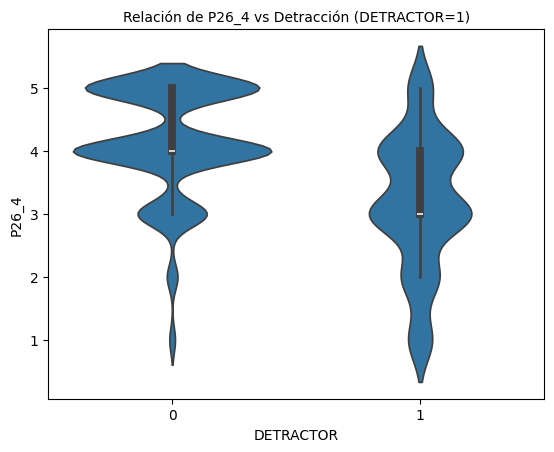

*** Prueba t para P26_4 ***
Estadístico t: -17.89595
Valor p: 0.00000
Se rechaza la hipótesis nula. Las medias son significativamente diferentes.
DETRACTOR
0    4.145691
1    3.177711
Name: P26_4, dtype: float64




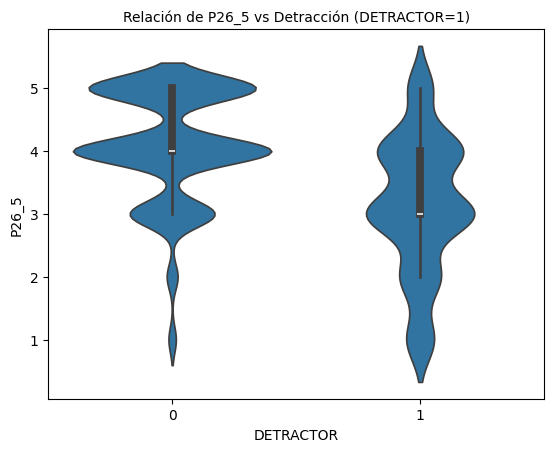

*** Prueba t para P26_5 ***
Estadístico t: -16.94191
Valor p: 0.00000
Se rechaza la hipótesis nula. Las medias son significativamente diferentes.
DETRACTOR
0    4.082079
1    3.138554
Name: P26_5, dtype: float64




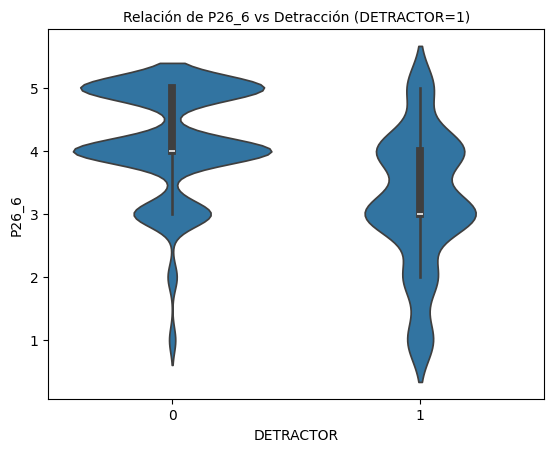

*** Prueba t para P26_6 ***
Estadístico t: -17.57749
Valor p: 0.00000
Se rechaza la hipótesis nula. Las medias son significativamente diferentes.
DETRACTOR
0    4.147059
1    3.192771
Name: P26_6, dtype: float64




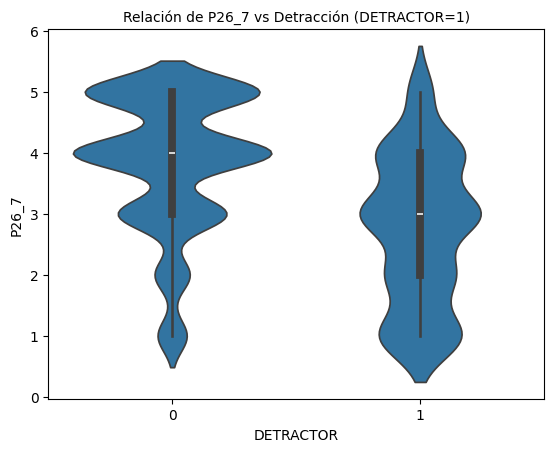

*** Prueba t para P26_7 ***
Estadístico t: -15.86819
Valor p: 0.00000
Se rechaza la hipótesis nula. Las medias son significativamente diferentes.
DETRACTOR
0    3.832421
1    2.743976
Name: P26_7, dtype: float64




In [66]:
for column in X.columns:
    title = f"Relación de {column} vs Detracción (DETRACTOR=1)"
    ml.analisis_variable_violin(estudiantes_CUSCO, "DETRACTOR", column, title)
    ml.prueba_t(estudiantes_CUSCO, 'DETRACTOR', column, 1, 0, XCopia)

Precisión del modelo con class_weight='balanced': 0.758
Reporte de clasificación con class_weight='balanced':
              precision    recall  f1-score   support

           0       0.94      0.75      0.83       294
           1       0.41      0.80      0.54        65

    accuracy                           0.76       359
   macro avg       0.68      0.77      0.69       359
weighted avg       0.85      0.76      0.78       359



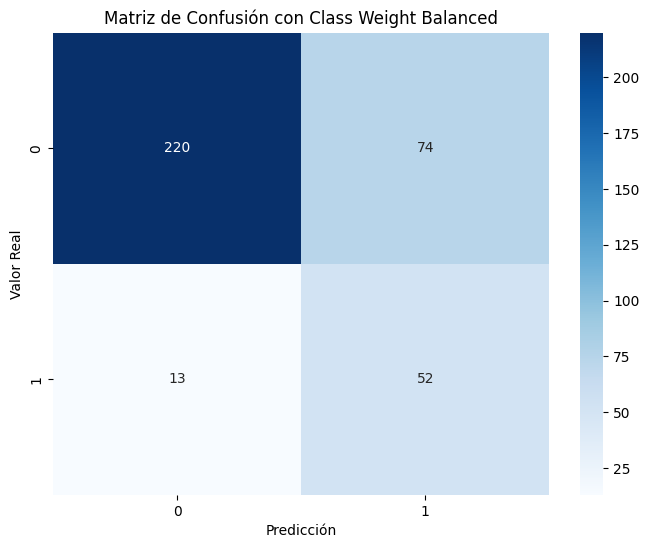

In [67]:
# Modelo de Regresión Logística con class_weight='balanced'
# Esto asignará automáticamente pesos inversamente proporcionales a las frecuencias de clase.

X_train, X_test, y_train, y_test = train_test_split(XCopia, y, test_size=0.2, random_state=42)

model_balanced = LogisticRegression(solver='liblinear', max_iter=300, random_state=50, class_weight='balanced')

model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
report_balanced = classification_report(y_test, y_pred_balanced)

print(f'Precisión del modelo con class_weight=\'balanced\': {accuracy_balanced:.3f}')
print(f'Reporte de clasificación con class_weight=\'balanced\':\n{report_balanced}')

# Graficar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_balanced), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión con Class Weight Balanced')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

**26.1 COMUNICACIÓN OPORTUNA A LOS ESTUDIANTES DE LOS BENEFICIOS, ESTÍMULOS Y NORMATIVAS DE LA UNIVERSIDAD**

**26.7 MONTO DE LA PENSIÓN**

**26.4 MEDIOS UTILIZADOS POR LA UNIVERSIDAD PARA LA COMUNICACIÓN CON EL ESTUDIANTE SON ADECUADAS**


  0%|          | 0/359 [00:00<?, ?it/s]

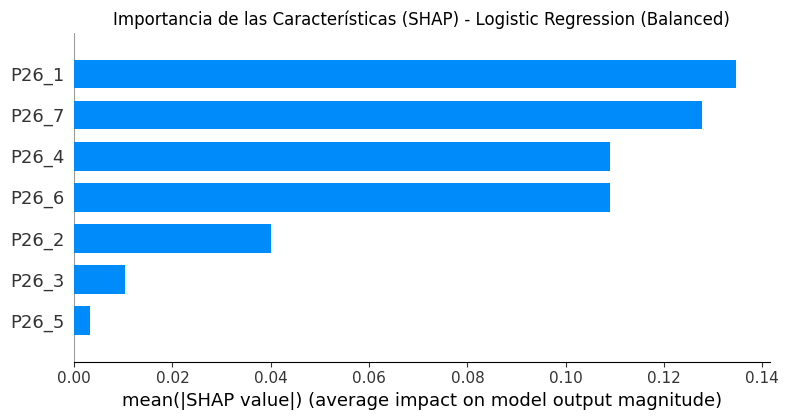

In [68]:
import shap

explainer = shap.KernelExplainer(model_balanced.predict, X_train)
shap_values = explainer.shap_values(X_test)

plt.title('Importancia de las Características (SHAP) - Logistic Regression (Balanced)')
shap.summary_plot(shap_values, X_test, feature_names=XCopia.columns, plot_type="bar")


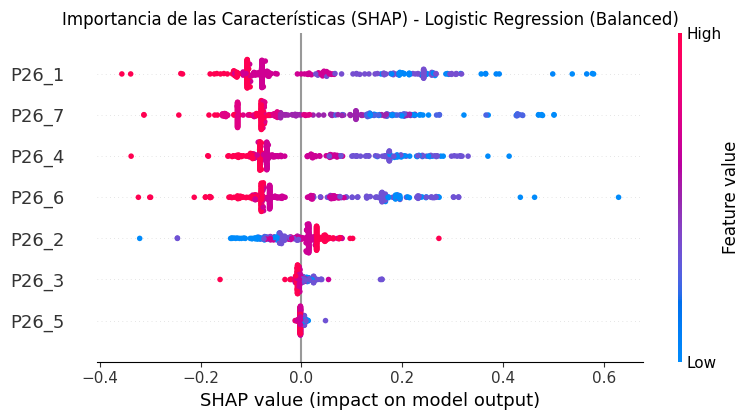

In [69]:

plt.title('Importancia de las Características (SHAP) - Logistic Regression (Balanced)')
shap.summary_plot(shap_values, X_test, feature_names=XCopia.columns)